This project used Python with pandas for handling the logs data, sqlite3 to store everything locally in a secure way, matplotlib and seaborn to show the reports in graphs. These packages help make the system easy to build and maintain, especially for small businesses who want local system without extra software.

**PART 1: Setup and Library Installation**

Import necessary packages and set up your environment.

In [ ]:
# Part 1: Setup and Install Required Libraries
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

**PART 2: Load and Preview Dataset**

Here, the user will upload their network log file in CSV format. The system loads this file and shows a preview of what is inside. This helps us understand the structure—usually includes timestamp, device name, event, and severity of issue.

In [ ]:
# Part 2: Load and Preview the Dataset
from google.colab import files
uploaded = files.upload()

# Load the CSV file into a DataFrame if uploading crosses certain limit will throw an error just to avoid the error in the colab I have used direct "read_csv"
# df = pd.read_csv("Enterprise_Network_Incident_Logs.csv")

# Preview the first few rows of the dataset
df.head()

Saving Enterprise_Network_Incident_Logs.csv to Enterprise_Network_Incident_Logs (1).csv


,Timestamp,Device_Name,Event_Type,Severity,Duration_Minutes,Source_IP,Destination_IP,Port_Number,Protocol,Resolved,issue_type
0,2024-01-30 19:40:00,access_point_y,connection lost,MEDIUM,49.0,192.168.237.90,10.0.129.255,3609,TLS,Yes,other
1,2024-01-27 22:56:00,firewall x,slow network,moderate,166.0,192.168.132.87,10.0.237.183,2230,QUIC,No,other
2,2024-02-06 19:00:00,db_z,firmware crash,critical,120.0,192.168.243.126,10.0.58.138,1682,tcp,Yes,other
3,2024-02-11 09:28:00,srv c,firmware crash,High,40.0,192.168.50.148,10.0.203.149,5976,tcp,No,other
4,2024-01-06 21:57:00,router a,slow network,LOW,133.0,192.168.68.238,10.0.83.33,6038,Tcp,Yes,other


**PART 3: Data Cleaning and Preprocessing**

Clean missing values, format timestamps, and remove duplicates.

In [ ]:
# Part 3: Data Cleaning and Preprocessing

# Remove rows with missing values
df.dropna(inplace=True)

# Convert timestamp to datetime object (assuming the column is named 'timestamp')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Remove rows with invalid timestamps
df = df[df['Timestamp'].notnull()]

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Standardize event type and device name to lowercase
df['Event_Type'] = df['Event_Type'].str.lower().str.strip()
df['Device_Name'] = df['Device_Name'].str.lower().str.strip()

# Preview after cleaning
df.head()

,Timestamp,Device_Name,Event_Type,Severity,Duration_Minutes,Source_IP,Destination_IP,Port_Number,Protocol,Resolved
0,2024-01-30 19:40:00,access_point_y,connection lost,MEDIUM,49.0,192.168.237.90,10.0.129.255,3609,TLS,Yes
41,2024-01-27 22:56:00,firewall x,slow network,moderate,166.0,192.168.132.87,10.0.237.183,2230,QUIC,No
50,2024-02-06 19:00:00,db_z,firmware crash,critical,120.0,192.168.243.126,10.0.58.138,1682,tcp,Yes
57,2024-02-11 09:28:00,srv c,firmware crash,High,40.0,192.168.50.148,10.0.203.149,5976,tcp,No
61,2024-01-06 21:57:00,router a,slow network,LOW,133.0,192.168.68.238,10.0.83.33,6038,Tcp,Yes


**PART 4: Issue Classification (Failure, Security, Performance)**

We create a new column issue_type to classify each incident as either a failure, a security event, or a performance issue based on the event description.

In [ ]:
# Part 4: Issue Classification

# Define lists of keywords for each type
failure_keywords = ['device down', 'link failure', 'packet loss', 'interface down']
security_keywords = ['intrusion detected', 'login failed', 'unauthorized access', 'malware']
performance_keywords = ['high latency', 'slow connection', 'bandwidth overload']

# Function to classify issue types
def classify_issue(event):
    event = event.lower()
    if any(word in event for word in failure_keywords):
        return 'failure'
    elif any(word in event for word in security_keywords):
        return 'security'
    elif any(word in event for word in performance_keywords):
        return 'performance'
    else:
        return 'other'

# Apply the function to create new column
df['issue_type'] = df['Event_Type'].apply(classify_issue)

# Display counts for each issue type to confirm classification
df['issue_type'].value_counts()

,count
issue_type,
other,194
performance,35
security,28
failure,25


**PART 5: SQLite Database Creation and Storage**

In this part, we connect to a local SQLite database and create tables to store our processed data. This supports data storage requirements from your project proposal and matches the section “Database Storage” in Solution Design.

In [ ]:
# Part 5: Store Data into SQLite Database

import sqlite3

# Create connection to SQLite database (will create if not exists)
conn = sqlite3.connect('network_logs.db')
cursor = conn.cursor()

# Drop tables if already exist to avoid duplicates (for re-runs)
cursor.execute("DROP TABLE IF EXISTS network_logs;")
cursor.execute("DROP TABLE IF EXISTS failures;")
cursor.execute("DROP TABLE IF EXISTS security_issues;")

# Create main table for all logs
cursor.execute('''
    CREATE TABLE network_logs (
        timestamp TEXT,
        device_name TEXT,
        event_type TEXT,
        severity TEXT,
        issue_type TEXT,
        Duration_Minutes REAL
    );
''')

# Insert data into main table
df.to_sql('network_logs', conn, if_exists='replace', index=False)

# Create failures table
cursor.execute('''
    CREATE TABLE failures AS
    SELECT * FROM network_logs WHERE issue_type = 'failure';
''')

# Create security_issues table
cursor.execute('''
    CREATE TABLE security_issues AS
    SELECT * FROM network_logs WHERE issue_type = 'security';
''')

# Commit and close
conn.commit()
conn.close()

print("✅ Data stored successfully in SQLite!")

✅ Data stored successfully in SQLite!


**PART 6: Analysis and Summary Preparation**

In this part, we will analyze the stored data to extract:

*   Most common failures and security issues
*   Devices with highest number of incidents
*   Dates or time periods with frequent issues
*   A summary table to show counts of different issue types

In [ ]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('network_logs.db')

# Load all data from the table
df_logs = pd.read_sql_query("SELECT * FROM network_logs", conn)

# Preview the data
df_logs.head()

,Timestamp,Device_Name,Event_Type,Severity,Duration_Minutes,Source_IP,Destination_IP,Port_Number,Protocol,Resolved,issue_type
0,2024-01-30 19:40:00,access_point_y,connection lost,MEDIUM,49.0,192.168.237.90,10.0.129.255,3609,TLS,Yes,other
1,2024-01-27 22:56:00,firewall x,slow network,moderate,166.0,192.168.132.87,10.0.237.183,2230,QUIC,No,other
2,2024-02-06 19:00:00,db_z,firmware crash,critical,120.0,192.168.243.126,10.0.58.138,1682,tcp,Yes,other
3,2024-02-11 09:28:00,srv c,firmware crash,High,40.0,192.168.50.148,10.0.203.149,5976,tcp,No,other
4,2024-01-06 21:57:00,router a,slow network,LOW,133.0,192.168.68.238,10.0.83.33,6038,Tcp,Yes,other


**Frequency of Issue Types**

Let’s count how many times each issue_type occurred.

In [ ]:
# Count each type of issue
issue_counts = df_logs['issue_type'].value_counts().reset_index()
issue_counts.columns = ['Issue Type', 'Count']
issue_counts

,Issue Type,Count
0,other,194
1,performance,35
2,security,28
3,failure,25


**Devices with Most Issues**

identify high-risk or problematic devices.

In [ ]:
# Count issues by device
device_issues = df_logs['Device_Name'].value_counts().reset_index()
device_issues.columns = ['Device Name', 'Number of Incidents']
device_issues

,Device Name,Number of Incidents
0,router a,51
1,server_c,38
2,srv c,37
3,switch-b,34
4,access_point_y,30
5,firewall x,30
6,db_z,25
7,load_balancer_1,23
8,edge_proxy,14


**Most Frequent Events**

 show which events (e.g., “Intrusion Detected”, “Link Down”) were most common.

In [ ]:
# Event type frequency
event_type_freq = df_logs['Event_Type'].value_counts().reset_index()
event_type_freq.columns = ['Event Type', 'Occurrences']
event_type_freq

,Event Type,Occurrences
0,ddos attack,42
1,high latency,35
2,slow network,35
3,firmware crash,34
4,connection lost,29
5,hardware failure,28
6,unauthorized access,28
7,downtime,26
8,packet loss,25


**Incidents Over Time**

help us make a line graph of issue frequency by date.

In [ ]:
# Convert timestamp column to datetime format
df_logs['Timestamp'] = pd.to_datetime(df_logs['Timestamp'])

# Group by date only
df_logs['date_only'] = df_logs['Timestamp'].dt.date
incidents_per_day = df_logs.groupby('date_only').size().reset_index(name='Total Incidents')
incidents_per_day.head()

,date_only,Total Incidents
0,2024-01-01,4
1,2024-01-02,7
2,2024-01-03,4
3,2024-01-04,4
4,2024-01-05,5


**Hourly Heatmap Preparation (for peak hours)**

In [ ]:
# Extract hour from timestamp
df_logs['hour'] = df_logs['Timestamp'].dt.hour

# Group by hour
incidents_by_hour = df_logs.groupby('hour').size().reset_index(name='Number of Incidents')
incidents_by_hour

,hour,Number of Incidents
0,0,11
1,1,10
2,2,13
3,3,12
4,4,7
5,5,7
6,6,12
7,7,8
8,8,13
9,9,13


**PART 7: Visualization and Reporting (Matplotlib Charts)**

This part shows the analytical findings using Matplotlib visualizations, which help users (non-technical) easily understand the patterns from the network logs. We’ll create:

A Bar Chart for issue types

A Bar Chart for devices with most incidents

A Line Graph of incidents over time

A Heatmap-style Bar Graph for hourly incident trends

**Bar Chart – Issue Types Distribution**

This chart helps identify the most frequent type of network problem (e.g., Failure vs. Security).

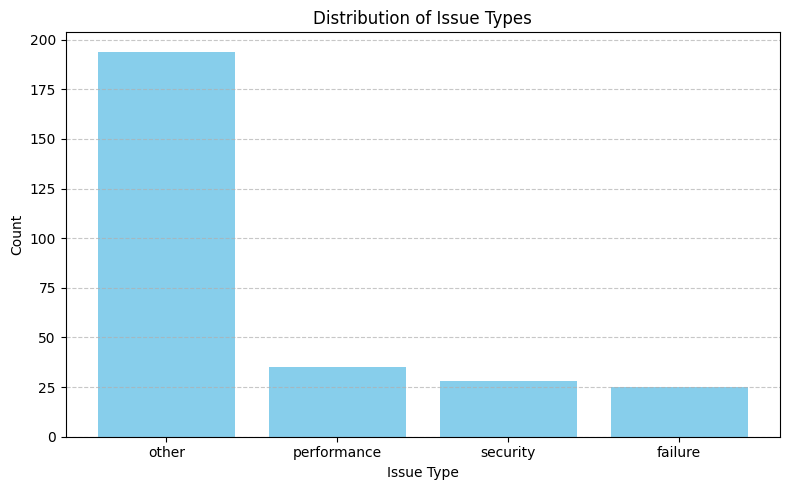

In [ ]:
import matplotlib.pyplot as plt

# Bar chart for issue type counts
plt.figure(figsize=(8, 5))
plt.bar(issue_counts['Issue Type'], issue_counts['Count'], color='skyblue')
plt.title('Distribution of Issue Types')
plt.xlabel('Issue Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("issue_types_distribution.png")
plt.show()

**Bar Chart – Devices with Most Issues**

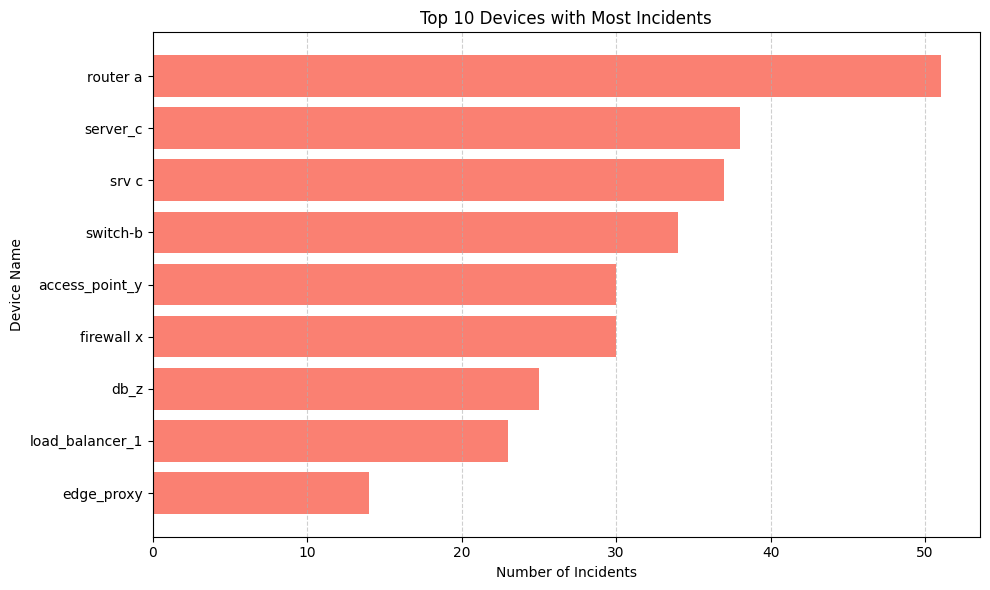

In [ ]:
# Top 10 devices with most issues
top_devices = device_issues.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_devices['Device Name'], top_devices['Number of Incidents'], color='salmon')
plt.title('Top 10 Devices with Most Incidents')
plt.xlabel('Number of Incidents')
plt.ylabel('Device Name')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("top_devices_issues.png")
plt.show()

**Line Graph – Incidents Over Time**

This shows which days had spikes in problems and helps investigate network outages.

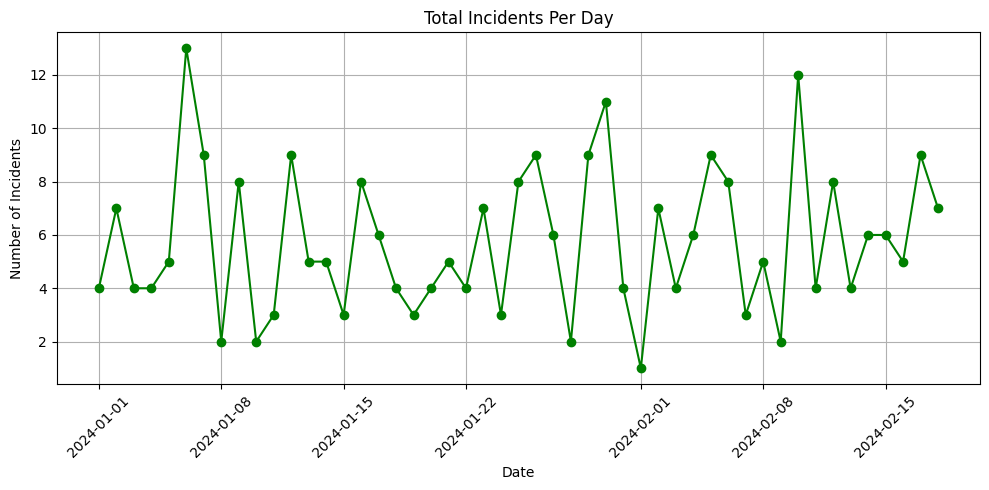

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(incidents_per_day['date_only'], incidents_per_day['Total Incidents'], marker='o', linestyle='-', color='green')
plt.title('Total Incidents Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("daily_incident_trend.png")
plt.show()

**Bar Graph – Hourly Trend (Heatmap Style)**

Helps detect which times of day the network is most unstable (e.g., peak usage hours).

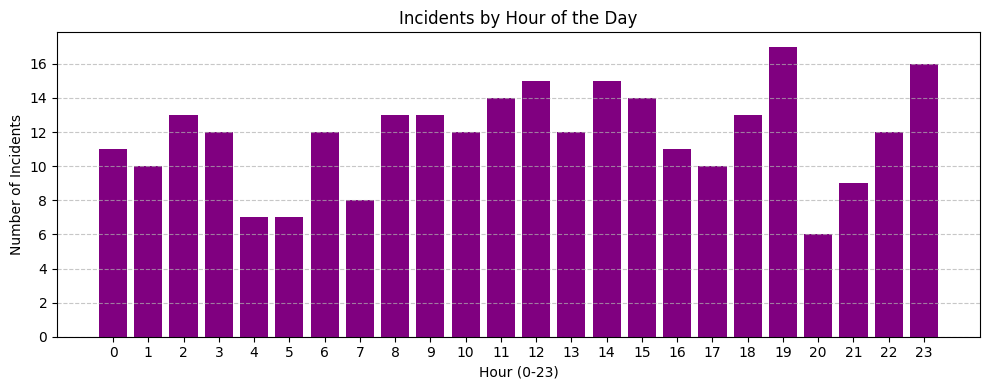

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(incidents_by_hour['hour'], incidents_by_hour['Number of Incidents'], color='purple')
plt.title('Incidents by Hour of the Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Incidents')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("hourly_issues.png")
plt.show()

**PART 8: Exporting Reports (CSV Summary File)**

We now generate a summary CSV report containing the final analysis results. This file is useful for documentation, emailing to managers, or long-term storage for audits.

**Create a Clean Summary Table**

We’ll combine our earlier analysis into a compact table that shows, for each device:

Total number of incidents

How many were failures

How many were security issues

In [ ]:
df['issue_type'].unique()

array(['other', 'security', 'performance', 'failure'], dtype=object)

In [ ]:
df[df['issue_type'].str.lower() == 'failure']

,Timestamp,Device_Name,Event_Type,Severity,Duration_Minutes,Source_IP,Destination_IP,Port_Number,Protocol,Resolved,issue_type
196,2024-01-04 16:29:00,router a,packet loss,critical,124.0,192.168.214.208,10.0.53.90,861,tcp,Yes,failure
277,2024-01-29 19:09:00,access_point_y,packet loss,MEDIUM,66.0,192.168.105.64,10.0.242.125,6670,Tcp,No,failure
299,2024-02-15 22:35:00,router a,packet loss,Severe,157.0,192.168.247.209,10.0.1.92,2383,ICMP,Yes,failure
605,2024-01-06 16:25:00,router a,packet loss,MEDIUM,67.0,192.168.241.235,10.0.34.23,7775,QUIC,No,failure
824,2024-01-31 19:16:00,firewall x,packet loss,CRITICAL,140.0,192.168.230.50,10.0.198.42,4403,udp,No,failure
1154,2024-02-12 13:52:00,srv c,packet loss,med,99.0,192.168.179.215,10.0.14.248,1432,ICMP,No,failure
1254,2024-01-09 03:30:00,server_c,packet loss,CRITICAL,64.0,192.168.74.192,10.0.254.199,3464,DNS,Yes,failure
1460,2024-01-12 06:11:00,router a,packet loss,high,77.0,192.168.100.77,10.0.76.74,7945,Tcp,No,failure
1539,2024-01-12 16:16:00,switch-b,packet loss,high,116.0,192.168.63.190,10.0.111.20,4136,QUIC,No,failure
1622,2024-01-07 07:12:00,access_point_y,packet loss,Severe,42.0,192.168.194.226,10.0.189.234,328,Tcp,Yes,failure


In [ ]:
df['issue_type'] = df['issue_type'].str.title()  # This makes values like 'failure' into 'Failure'

In [ ]:
failures = df[df['issue_type'] == 'Failure']
security = df[df['issue_type'] == 'Security']

In [ ]:
# Count failures per device
failures_per_device = failures['Device_Name'].value_counts().reset_index()
failures_per_device.columns = ['Device_Name', 'failure_count']

# Count security issues per device
security_per_device = security['Device_Name'].value_counts().reset_index()
security_per_device.columns = ['Device_Name', 'security_count']

# Merge
summary_df = pd.merge(failures_per_device, security_per_device, on='Device_Name', how='outer')
summary_df = summary_df.fillna(0)
summary_df['total_incidents'] = summary_df['failure_count'] + summary_df['security_count']
summary_df = summary_df.sort_values(by='total_incidents', ascending=False).reset_index(drop=True)

summary_df.head()

,Device_Name,failure_count,security_count,total_incidents
0,router a,6.0,9,15.0
1,srv c,5.0,5,10.0
2,switch-b,3.0,4,7.0
3,server_c,4.0,3,7.0
4,firewall x,3.0,1,4.0


In [ ]:
summary_df.to_csv('Network_Incident_Summary_Report.csv', index=False)
print("✅ Summary report saved as 'Network_Incident_Summary_Report.csv'")

✅ Summary report saved as 'Network_Incident_Summary_Report.csv'


**Export Data from SQLite to CSV**

In [ ]:
import sqlite3
import pandas as pd

# Connect to your SQLite database
conn = sqlite3.connect('network_logs.db')

# Query to retrieve data
query = "SELECT * FROM network_logs"
df = pd.read_sql_query(query, conn)

# Save to CSV
df.to_csv('network_logs_export.csv', index=False)

# Close the connection
conn.close()